In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class MLP(nn.Module):
    def __init__(self, layers=1, in_dim=2, hidden=64, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            *[nn.Tanh(),
            nn.Linear(hidden, hidden)]*layers,
            nn.Tanh(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, x):
        return self.net(x)
    
class AutoEncoder(nn.Module):
    def __init__(self, layers=1, in_dim=2, hidden=64, out_dim=2):
        self.encoder = MLP(layers, in_dim, hidden=64, out_dim=hidden)
        self.decoder = MLP(layers, in_dim=hidden, hidden=hidden, out_dim=out_dim)

    def forward(self, x):
        y = self.encoder(x)
        return self.decoder(y)



Final NLL (avg last 50): 0.013398109674453736
mean ~ [-0.00298059 -0.00794557] 
Cov ~
 [[ 0.89124849 -0.04300766]
 [-0.04300766  0.91832205]]
corr(u1, score) = 0.107,  corr(u2, score) = -0.061,  corr(||u-0.5||, score) = 0.799


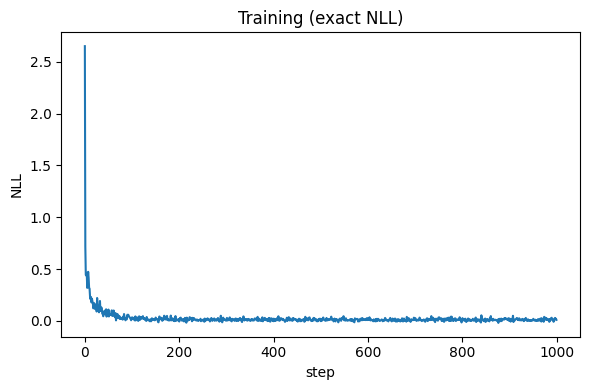

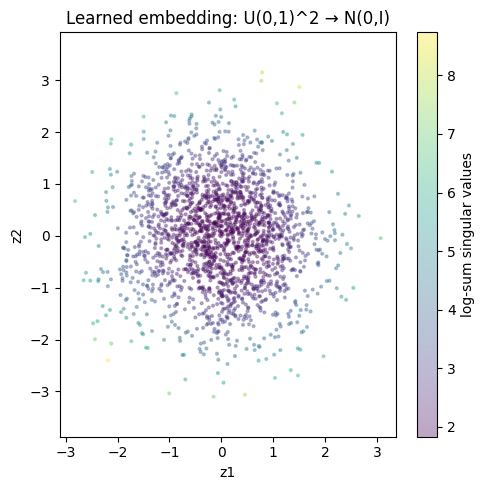

In [1]:
# ===============================================================
# Crash-safe Gaussian embedding + per-sample Jacobian scores
# ===============================================================
import math, gc, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(1); np.random.seed(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------- Data --------------------
def sample_uniform(n):  # (0,1)^2
    return torch.rand(n, 2, device=device)

# -------------------- Pre-transform: logit --------------------
def logit(u, eps=1e-6):
    u = u.clamp(eps, 1-eps)
    x = torch.log(u) - torch.log(1 - u)
    logabsdet = (-torch.log(u) - torch.log(1 - u)).sum(dim=1)
    return x, logabsdet

# -------------------- Prior (standard normal) --------------------
def standard_normal_nll(z):
    return 0.5*(z**2).sum(dim=1) + 0.5*z.size(1)*math.log(2*math.pi)

# -------------------- RealNVP (2D) --------------------
class Coupling(nn.Module):
    def __init__(self, mask):
        super().__init__()
        self.register_buffer("mask", torch.tensor(mask, dtype=torch.float32))
        hid = 64
        self.s = nn.Sequential(nn.Linear(2,hid), nn.GELU(),
                               nn.Linear(hid,hid), nn.GELU(),
                               nn.Linear(hid,2), nn.Tanh())
        self.t = nn.Sequential(nn.Linear(2,hid), nn.GELU(),
                               nn.Linear(hid,hid), nn.GELU(),
                               nn.Linear(hid,2))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="linear")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x1 = x * self.mask
        s = self.s(x1) * (1 - self.mask)
        t = self.t(x1) * (1 - self.mask)
        y = x1 + (1 - self.mask) * (x * torch.exp(s) + t)
        logabsdet = s.sum(dim=1)
        return y, logabsdet

    def inverse(self, y):
        y1 = y * self.mask
        s = self.s(y1) * (1 - self.mask)
        t = self.t(y1) * (1 - self.mask)
        x = y1 + (1 - self.mask) * ((y - t) * torch.exp(-s))
        logabsdet = -s.sum(dim=1)
        return x, logabsdet

class Flow(nn.Module):
    def __init__(self, K=4):
        super().__init__()
        masks = [[1.,0.],[0.,1.]] * (K//2)
        if K % 2 == 1: masks.append([1.,0.])
        self.layers = nn.ModuleList([Coupling(m) for m in masks])

    def forward(self, x):
        logdet = torch.zeros(x.size(0), device=x.device)
        h = x
        for layer in self.layers:
            h, ld = layer(h); logdet += ld
        return h, logdet

flow = Flow(K=4).to(device)

# -------------------- Train (small, safe) --------------------
opt = torch.optim.Adam(flow.parameters(), lr=2e-3)
steps, batch = 1000, 256   # keep modest; increase later if desired
loss_hist = []

for t in range(steps):
    u = sample_uniform(batch)
    x, ld_logit = logit(u)
    z, ld_flow  = flow(x)
    nll = standard_normal_nll(z) - (ld_logit + ld_flow)
    loss = nll.mean()
    opt.zero_grad(); loss.backward(); opt.step()
    loss_hist.append(loss.item())

print("Final NLL (avg last 50):", np.mean(loss_hist[-50:]))

# -------------------- Wrapper f(u) --------------------
class UniformToGaussian(nn.Module):
    def __init__(self, flow, eps=1e-6):
        super().__init__()
        self.flow = flow; self.eps = eps
    def forward(self, u):
        x, _ = logit(u, eps=self.eps)
        z, _ = self.flow(x)
        return z

model = UniformToGaussian(flow).to(device).eval()

# -------------------- Evaluation --------------------
with torch.no_grad():
    n_eval = 4000     # modest to avoid crashes
    U = sample_uniform(n_eval)
    Z = model(U)
Z_np = Z.cpu().numpy()
print("mean ~", Z_np.mean(0), "\nCov ~\n", np.cov(Z_np.T))

# -------------------- Per-sample Jacobian (no O(B^2)) --------------------
def per_sample_jacobian(model, U, chunk=256):
    """
    Returns J of shape [N, 2, 2] computed in chunks to limit memory.
    Uses torch.func.jacrev + vmap if available; else single-sample loop.
    """
    N = U.shape[0]
    J_out = torch.empty(N, 2, 2, device=U.device, dtype=U.dtype)
    use_func = False
    try:
        from torch.func import jacrev, vmap
        use_func = True
        def f_single(x):             # (2,) -> (2,)
            return model(x.unsqueeze(0)).squeeze(0)
        jf = jacrev(f_single)
        for s in range(0, N, chunk):
            e = min(s+chunk, N)
            J_out[s:e] = vmap(jf)(U[s:e])
    except Exception:
        # Fallback: loop (slower but safe)
        U.requires_grad_(True)
        for i in range(N):
            ui = U[i:i+1]            # [1,2]
            z = model(ui)            # [1,2]
            J = []
            for k in range(2):
                (grad,) = torch.autograd.grad(z[0,k], ui, retain_graph=True, create_graph=False)
                J.append(grad[0])
            J_out[i] = torch.stack(J, dim=0)   # [2,2]
            if (i+1) % 256 == 0:
                gc.collect()
    return J_out

J = per_sample_jacobian(model, U, chunk=256)  # [N, 2, 2]

# -------------------- JEPA-like score --------------------
sv = torch.linalg.svdvals(J)                   # [N, 2]
jepa_score = torch.log(sv.clamp_min(1e-6)).sum(-1)  # [N]

# -------------------- Correlations --------------------
def corr(a, b):
    C = torch.corrcoef(torch.stack([a, b]))
    return C[0,1].item()
c_u1 = corr(U[:,0].cpu(), jepa_score.cpu())
c_u2 = corr(U[:,1].cpu(), jepa_score.cpu())
c_center = corr(torch.linalg.norm(U-0.5, dim=1).cpu(), jepa_score.cpu())
print(f"corr(u1, score) = {c_u1:.3f},  corr(u2, score) = {c_u2:.3f},  corr(||u-0.5||, score) = {c_center:.3f}")

# -------------------- Plots (small, safe) --------------------
plt.figure(figsize=(6,4))
plt.plot(loss_hist); plt.xlabel("step"); plt.ylabel("NLL"); plt.title("Training (exact NLL)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(5,5))
sc = plt.scatter(Z_np[:2000,0], Z_np[:2000,1], s=4, alpha=0.35, c=jepa_score[:2000].cpu().numpy())
plt.colorbar(sc, label="log-sum singular values")
plt.title("Learned embedding: U(0,1)^2 → N(0,I)")
plt.xlabel("z1"); plt.ylabel("z2"); plt.axis("equal")
plt.tight_layout(); plt.show()


Train size: 242 | Test size: 61
Class balance train: {0: 0.6446280991735537, 1: 0.35537190082644626}
Class balance test : {1: 0.5081967213114754, 0: 0.4918032786885246}
PR-AUC by C (L2, ALL): {0.05: 0.4044, 0.1: 0.4076, 0.2: 0.4058, 0.5: 0.4135, 1: 0.4294, 2: 0.4306, 5: 0.4355, 10: 0.4315}

=== L2 ALL (C=5) ===
ROC AUC: 0.7065 | PR AUC: 0.7026 | Brier: 0.2334

-- @ threshold 0.5 --
              precision    recall  f1-score   support

           0      0.556     0.667     0.606        30
           1      0.600     0.484     0.536        31

    accuracy                          0.574        61
   macro avg      0.578     0.575     0.571        61
weighted avg      0.578     0.574     0.570        61

Confusion Matrix @0.5:
 [[20 10]
 [16 15]]

Best F1 threshold: 0.300
-- @ best F1 threshold --
              precision    recall  f1-score   support

           0      0.789     0.500     0.612        30
           1      0.643     0.871     0.740        31

    accuracy                 

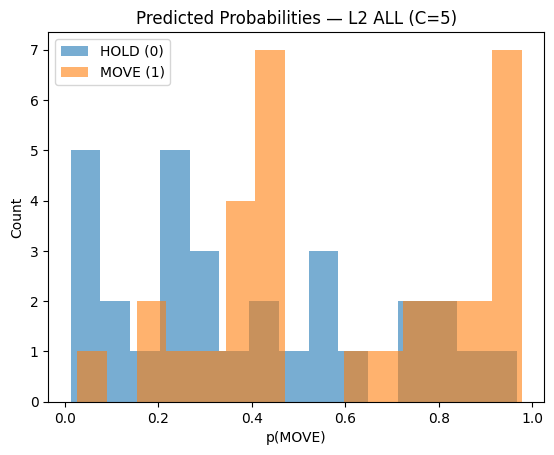


=== L2 ALL + SigmoidCal (C=5) ===
ROC AUC: 0.5409 | PR AUC: 0.6008 | Brier: 0.2636

-- @ threshold 0.5 --
              precision    recall  f1-score   support

           0      0.492     1.000     0.659        30
           1      0.000     0.000     0.000        31

    accuracy                          0.492        61
   macro avg      0.246     0.500     0.330        61
weighted avg      0.242     0.492     0.324        61

Confusion Matrix @0.5:
 [[30  0]
 [31  0]]

Best F1 threshold: 0.328
-- @ best F1 threshold --
              precision    recall  f1-score   support

           0      1.000     0.033     0.065        30
           1      0.517     1.000     0.681        31

    accuracy                          0.525        61
   macro avg      0.758     0.517     0.373        61
weighted avg      0.754     0.525     0.378        61

Confusion Matrix @best:
 [[ 1 29]
 [ 0 31]]

Most negative coeffs (→ HOLD):
work_force_l1      -1.383213
last_year_icp_l1   -1.091188
m_12      

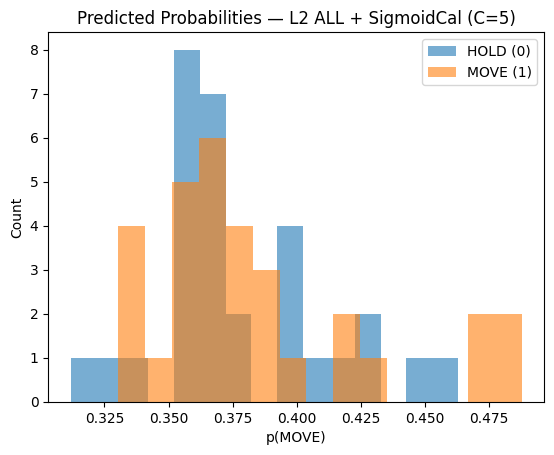

ElasticNet (ALL) best l1_ratio=0.8, C=2, PR-CV=0.4376

=== ElasticNet ALL (C=2, l1=0.8) ===
ROC AUC: 0.6946 | PR AUC: 0.6962 | Brier: 0.2298

-- @ threshold 0.5 --
              precision    recall  f1-score   support

           0      0.568     0.700     0.627        30
           1      0.625     0.484     0.545        31

    accuracy                          0.590        61
   macro avg      0.596     0.592     0.586        61
weighted avg      0.597     0.590     0.585        61

Confusion Matrix @0.5:
 [[21  9]
 [16 15]]

Best F1 threshold: 0.314
-- @ best F1 threshold --
              precision    recall  f1-score   support

           0      0.789     0.500     0.612        30
           1      0.643     0.871     0.740        31

    accuracy                          0.689        61
   macro avg      0.716     0.685     0.676        61
weighted avg      0.715     0.689     0.677        61

Confusion Matrix @best:
 [[15 15]
 [ 4 27]]

Most negative coeffs (→ HOLD):
work_force_

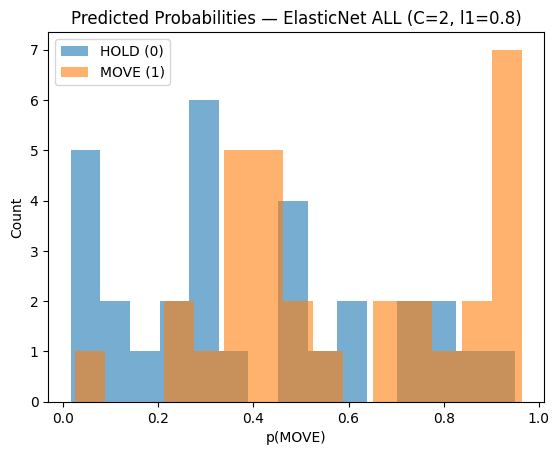


=== ElasticNet ALL + SigmoidCal (C=2, l1=0.8) ===
ROC AUC: 0.5624 | PR AUC: 0.5412 | Brier: 0.2682

-- @ threshold 0.5 --
              precision    recall  f1-score   support

           0      0.483     0.967     0.644        30
           1      0.000     0.000     0.000        31

    accuracy                          0.475        61
   macro avg      0.242     0.483     0.322        61
weighted avg      0.238     0.475     0.317        61

Confusion Matrix @0.5:
 [[29  1]
 [31  0]]

Best F1 threshold: 0.307
-- @ best F1 threshold --
              precision    recall  f1-score   support

           0      1.000     0.033     0.065        30
           1      0.517     1.000     0.681        31

    accuracy                          0.525        61
   macro avg      0.758     0.517     0.373        61
weighted avg      0.754     0.525     0.378        61

Confusion Matrix @best:
 [[ 1 29]
 [ 0 31]]

Most negative coeffs (→ HOLD):
work_force_l1      -0.828747
last_year_icp_l1   -0.6

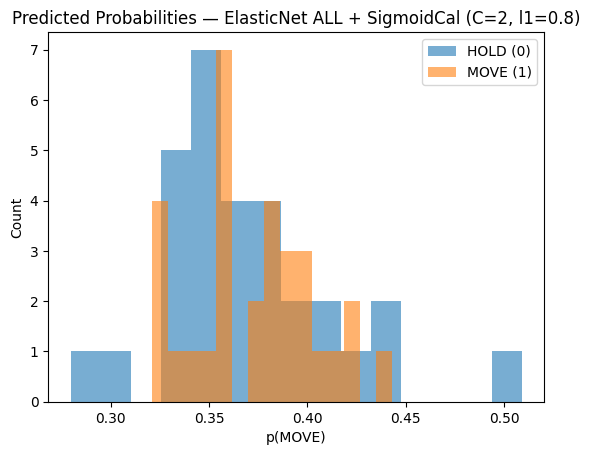

PR-AUC by C (L2, NO-MONTH): {0.05: 0.4541, 0.1: 0.4523, 0.2: 0.4651, 0.5: 0.4557, 1: 0.4497, 2: 0.4495, 5: 0.4345, 10: 0.4207}

=== L2 NO-MONTH (C=0.2) ===
ROC AUC: 0.7000 | PR AUC: 0.7001 | Brier: 0.2250

-- @ threshold 0.5 --
              precision    recall  f1-score   support

           0      0.571     0.667     0.615        30
           1      0.615     0.516     0.561        31

    accuracy                          0.590        61
   macro avg      0.593     0.591     0.588        61
weighted avg      0.594     0.590     0.588        61

Confusion Matrix @0.5:
 [[20 10]
 [15 16]]

Best F1 threshold: 0.414
-- @ best F1 threshold --
              precision    recall  f1-score   support

           0      0.789     0.500     0.612        30
           1      0.643     0.871     0.740        31

    accuracy                          0.689        61
   macro avg      0.716     0.685     0.676        61
weighted avg      0.715     0.689     0.677        61

Confusion Matrix @best:

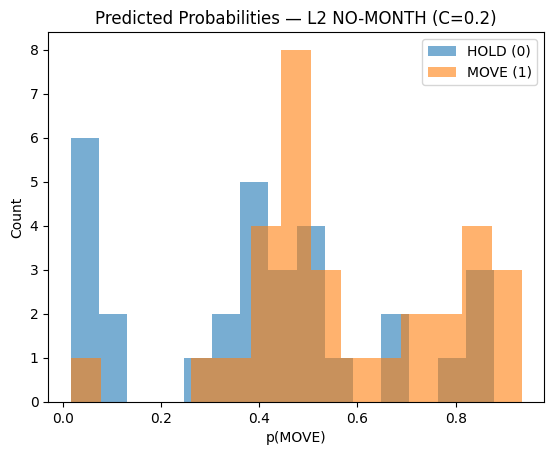

PR-AUC by C (L2, PARS): {0.05: 0.3851, 0.1: 0.388, 0.2: 0.3884, 0.5: 0.3931, 1: 0.3946, 2: 0.3919, 5: 0.3842, 10: 0.3809}

=== L2 PARS (C=1) ===
ROC AUC: 0.6065 | PR AUC: 0.6157 | Brier: 0.2535

-- @ threshold 0.5 --
              precision    recall  f1-score   support

           0      0.609     0.467     0.528        30
           1      0.579     0.710     0.638        31

    accuracy                          0.590        61
   macro avg      0.594     0.588     0.583        61
weighted avg      0.594     0.590     0.584        61

Confusion Matrix @0.5:
 [[14 16]
 [ 9 22]]

Best F1 threshold: 0.377
-- @ best F1 threshold --
              precision    recall  f1-score   support

           0      0.750     0.100     0.176        30
           1      0.526     0.968     0.682        31

    accuracy                          0.541        61
   macro avg      0.638     0.534     0.429        61
weighted avg      0.636     0.541     0.433        61

Confusion Matrix @best:
 [[ 3 27]


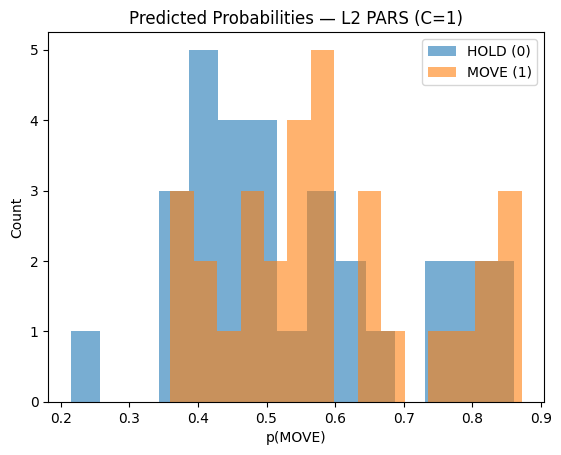


=== L2 PARS + SigmoidCal (C=1) ===
ROC AUC: 0.5000 | PR AUC: 0.5017 | Brier: 0.2815

-- @ threshold 0.5 --
              precision    recall  f1-score   support

           0      0.492     1.000     0.659        30
           1      0.000     0.000     0.000        31

    accuracy                          0.492        61
   macro avg      0.246     0.500     0.330        61
weighted avg      0.242     0.492     0.324        61

Confusion Matrix @0.5:
 [[30  0]
 [31  0]]

Best F1 threshold: 0.290
-- @ best F1 threshold --
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        30
           1      0.508     1.000     0.674        31

    accuracy                          0.508        61
   macro avg      0.254     0.500     0.337        61
weighted avg      0.258     0.508     0.342        61

Confusion Matrix @best:
 [[ 0 30]
 [ 0 31]]

Most negative coeffs (→ HOLD):
month_ipc_l1      -0.228621
unemploy_rate     -0.157798
tpm_l1     

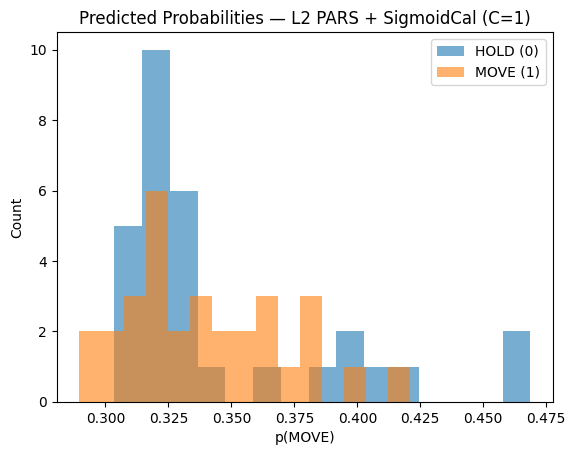


[Done] Reviewed all ablations.


In [17]:
# ============================================
# Policy move (Δ≠0) logistic regression — full script
# - Feature engineering: lags, deltas, optional month FE
# - Chronological split (80/20)
# - Standardization on train only
# - Time-aware CV to tune C by PR AUC
# - Variants: L2 vs Elastic Net; with/without sigmoid calibration
# - Ablations: ALL features, NO-MONTH, PARSIMONIOUS
# - Robust coefficient extraction for CalibratedClassifierCV
# ============================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, brier_score_loss, precision_recall_curve
)

# ----------------------------
# Utility helpers
# ----------------------------
def extract_logit_coefficients(trained_clf, feature_names):
    """
    Return a Series of coefficients aligned to feature_names.
    Works for plain LogisticRegression and CalibratedClassifierCV (averages across folds).
    """
    # Case 1: calibrated model (sklearn >=1.1 exposes calibrated_classifiers_)
    if hasattr(trained_clf, "calibrated_classifiers_"):
        coefs = []
        for cc in trained_clf.calibrated_classifiers_:
            # sklearn >=1.4 uses 'estimator'; older used 'base_estimator'
            est = getattr(cc, "estimator", getattr(cc, "base_estimator", None))
            if est is not None and hasattr(est, "coef_"):
                coefs.append(est.coef_[0])
        if coefs:
            coef_vec = np.mean(np.vstack(coefs), axis=0)
            return pd.Series(coef_vec, index=feature_names)
        return None

    # Case 2: plain logistic
    if hasattr(trained_clf, "coef_"):
        return pd.Series(trained_clf.coef_[0], index=feature_names)

    return None

def fit_eval_logit(
    X_train_s, y_train, X_test_s, y_test,
    C=1.0, penalty='l2', l1_ratio=None,
    class_weight='balanced',
    calibrate=False, calib_method='sigmoid',
    tscv=None, label='model',
    feature_names=None,
    plot_hist=True
):
    """
    Fit a logistic model (optionally calibrated) and evaluate on test.
    Returns (trained_classifier, y_prob, best_threshold).
    """
    base = LogisticRegression(
        C=C, penalty=penalty, l1_ratio=l1_ratio,
        solver='saga' if penalty=='elasticnet' else 'lbfgs',
        class_weight=class_weight, max_iter=5000
    )

    if calibrate:
        assert tscv is not None, "Provide TimeSeriesSplit for calibration."
        clf = CalibratedClassifierCV(base, method=calib_method, cv=tscv)
        clf.fit(X_train_s, y_train)
    else:
        base.fit(X_train_s, y_train)
        clf = base

    # Predict probabilities
    y_prob = clf.predict_proba(X_test_s)[:, 1]

    # Threshold-free metrics
    roc = roc_auc_score(y_test, y_prob)
    pr  = average_precision_score(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)

    # Default 0.5 metrics
    y_pred_05 = (y_prob >= 0.5).astype(int)

    # Best F1 threshold (note: for production, compute on a validation fold)
    prec, rec, thr = precision_recall_curve(y_test, y_prob)
    f1 = (2*prec*rec)/(prec+rec+1e-12)
    best_idx = int(np.nanargmax(f1))
    best_thr = float(thr[max(best_idx-1,0)]) if len(thr)>0 else 0.5
    y_pred_best = (y_prob >= best_thr).astype(int)

    print(f"\n=== {label} ===")
    print(f"ROC AUC: {roc:.4f} | PR AUC: {pr:.4f} | Brier: {brier:.4f}")
    print("\n-- @ threshold 0.5 --")
    print(classification_report(y_test, y_pred_05, digits=3, zero_division=0))
    print("Confusion Matrix @0.5:\n", confusion_matrix(y_test, y_pred_05))
    print(f"\nBest F1 threshold: {best_thr:.3f}")
    print("-- @ best F1 threshold --")
    print(classification_report(y_test, y_pred_best, digits=3, zero_division=0))
    print("Confusion Matrix @best:\n", confusion_matrix(y_test, y_pred_best))

    # Coefficients
    if feature_names is not None:
        coef_ser = extract_logit_coefficients(clf, feature_names)
        if coef_ser is not None:
            coef_sorted = coef_ser.sort_values()
            print("\nMost negative coeffs (→ HOLD):")
            print(coef_sorted.head(min(10, len(coef_sorted))))
            print("\nMost positive coeffs (→ MOVE):")
            print(coef_sorted.tail(min(10, len(coef_sorted))))
        else:
            print("\n[Info] Could not extract coefficients (estimator does not expose coef_).")

    # Optional probability histogram (diagnostic)
    if plot_hist:
        plt.figure()
        plt.hist(y_prob[y_test==0], bins=15, alpha=0.6, label='HOLD (0)')
        plt.hist(y_prob[y_test==1], bins=15, alpha=0.6, label='MOVE (1)')
        plt.title(f"Predicted Probabilities — {label}")
        plt.xlabel("p(MOVE)")
        plt.ylabel("Count")
        plt.legend()
        plt.show()

    return clf, y_prob, best_thr

def tune_logit_C(
    X_train_s, y_train, tscv, penalty='l2', l1_ratio=None,
    C_grid=None, class_weight='balanced', score='pr'
):
    """
    Time-aware CV tuning of C. score='pr' (PR AUC) or 'roc' (ROC AUC).
    Returns (best_C, [(C, mean_score), ...]).
    """
    if C_grid is None:
        C_grid = [0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]

    results = []
    for C in C_grid:
        m = LogisticRegression(
            C=C, penalty=penalty, l1_ratio=l1_ratio,
            solver='saga' if penalty=='elasticnet' else 'lbfgs',
            class_weight=class_weight, max_iter=5000
        )
        fold_scores = []
        for tr, va in tscv.split(X_train_s):
            m.fit(X_train_s[tr], y_train.iloc[tr])
            p = m.predict_proba(X_train_s[va])[:,1]
            if score == 'pr':
                fold_scores.append(average_precision_score(y_train.iloc[va], p))
            else:
                fold_scores.append(roc_auc_score(y_train.iloc[va], p))
        results.append((C, float(np.mean(fold_scores))))
    best_C, best_score = max(results, key=lambda x: x[1])
    return best_C, results

# ----------------------------
# Load data & feature engineering
# ----------------------------
EXCEL_PATH = "macrodata.xlsx"

df = pd.read_excel(EXCEL_PATH)
df['meeting_date'] = pd.to_datetime(df['meeting_date'])
df = df.sort_values('meeting_date').reset_index(drop=True)

# Target: 1 if policy move (Δ != 0), else 0 (hold)
df['target'] = (df['delta'] != 0).astype(int)

# Lags (1 meeting back)
lag_cols = [
    'tpm', 'month_ipc', 'year_icp', 'last_year_icp',
    'work_force', 'employed', 'unemployed', 'unemploy_rate'
]
for col in lag_cols:
    df[f'{col}_l1'] = df[col].shift(1)

# Deltas
df['d_tpm'] = df['tpm'] - df['tpm_l1']
df['d_year_icp'] = df['year_icp'] - df['year_icp_l1']
df['d_unemploy_rate'] = df['unemploy_rate'] - df['unemploy_rate_l1']

# Month FE (optional)
df['month'] = df['meeting_date'].dt.month
month_dum = pd.get_dummies(df['month'], prefix='m', drop_first=True)

# Feature sets
drop_cols_base = ['delta','target','date','meeting_date','month']  # 'date' if present

X_all = pd.concat([df.drop(columns=drop_cols_base, errors='ignore'), month_dum], axis=1).fillna(0)
X_no_month = df.drop(columns=drop_cols_base + list(month_dum.columns), errors='ignore').fillna(0)

pars_cols = [
    'tpm','tpm_l1','year_icp','d_year_icp',
    'unemploy_rate','d_unemploy_rate','month_ipc_l1'
]
X_pars = df[[c for c in pars_cols if c in df.columns]].fillna(0)

y = df['target'].astype(int)

# Chronological split (80/20)
split_idx = int(0.8 * len(df))
def split_and_scale(X):
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test, X_train_s, X_test_s, scaler

print(f"Train size: {split_idx} | Test size: {len(df)-split_idx}")
print("Class balance train:", y.iloc[:split_idx].value_counts(normalize=True).to_dict())
print("Class balance test :", y.iloc[split_idx:].value_counts(normalize=True).to_dict())

tscv = TimeSeriesSplit(n_splits=5)

# ----------------------------
# Ablation 1: L2, no calibration, ALL features
# ----------------------------
X_train, X_test, y_train, y_test, X_train_s, X_test_s, scaler = split_and_scale(X_all)
bestC_l2_all, table_l2_all = tune_logit_C(X_train_s, y_train, tscv, penalty='l2', score='pr')
print("PR-AUC by C (L2, ALL):", {C: round(s,4) for C,s in table_l2_all})

_ = fit_eval_logit(
    X_train_s, y_train, X_test_s, y_test,
    C=bestC_l2_all, penalty='l2', calibrate=False, tscv=tscv,
    label=f"L2 ALL (C={bestC_l2_all})",
    feature_names=X_all.columns, plot_hist=True
)

# ----------------------------
# Ablation 2: L2 + SIGMOID calibration, ALL features
# ----------------------------
_ = fit_eval_logit(
    X_train_s, y_train, X_test_s, y_test,
    C=bestC_l2_all, penalty='l2', calibrate=True, calib_method='sigmoid',
    tscv=tscv, label=f"L2 ALL + SigmoidCal (C={bestC_l2_all})",
    feature_names=X_all.columns, plot_hist=True
)

# ----------------------------
# Ablation 3: Elastic Net (L1+L2), ALL features (+cal/no-cal)
# ----------------------------
# Coarse search over l1_ratio
def best_elastic_net_params(X_train_s, y_train, tscv, l1_grid=(0.2,0.4,0.6,0.8)):
    best = {'l1_ratio': None, 'C': None, 'score': -np.inf}
    for lr in l1_grid:
        C_tmp, res_tmp = tune_logit_C(X_train_s, y_train, tscv, penalty='elasticnet', l1_ratio=lr, score='pr')
        mean_tmp = dict(res_tmp)[C_tmp]
        if mean_tmp > best['score']:
            best.update({'l1_ratio': lr, 'C': C_tmp, 'score': mean_tmp})
    return best

en_best = best_elastic_net_params(X_train_s, y_train, tscv)
print(f"ElasticNet (ALL) best l1_ratio={en_best['l1_ratio']}, C={en_best['C']}, PR-CV={en_best['score']:.4f}")

_ = fit_eval_logit(
    X_train_s, y_train, X_test_s, y_test,
    C=en_best['C'], penalty='elasticnet', l1_ratio=en_best['l1_ratio'],
    calibrate=False, tscv=tscv, label=f"ElasticNet ALL (C={en_best['C']}, l1={en_best['l1_ratio']})",
    feature_names=X_all.columns, plot_hist=True
)

_ = fit_eval_logit(
    X_train_s, y_train, X_test_s, y_test,
    C=en_best['C'], penalty='elasticnet', l1_ratio=en_best['l1_ratio'],
    calibrate=True, calib_method='sigmoid', tscv=tscv,
    label=f"ElasticNet ALL + SigmoidCal (C={en_best['C']}, l1={en_best['l1_ratio']})",
    feature_names=X_all.columns, plot_hist=True
)

# ----------------------------
# Ablation 4: Remove month FE (ALL - month dummies)
# ----------------------------
X_train, X_test, y_train, y_test, X_train_s, X_test_s, scaler = split_and_scale(X_no_month)
bestC_l2_nm, table_l2_nm = tune_logit_C(X_train_s, y_train, tscv, penalty='l2', score='pr')
print("PR-AUC by C (L2, NO-MONTH):", {C: round(s,4) for C,s in table_l2_nm})

_ = fit_eval_logit(
    X_train_s, y_train, X_test_s, y_test,
    C=bestC_l2_nm, penalty='l2', calibrate=False, tscv=tscv,
    label=f"L2 NO-MONTH (C={bestC_l2_nm})",
    feature_names=X_no_month.columns, plot_hist=True
)

# ----------------------------
# Ablation 5: Parsimonious feature set
# ----------------------------
X_train, X_test, y_train, y_test, X_train_s, X_test_s, scaler = split_and_scale(X_pars)
bestC_l2_pars, table_l2_pars = tune_logit_C(X_train_s, y_train, tscv, penalty='l2', score='pr')
print("PR-AUC by C (L2, PARS):", {C: round(s,4) for C,s in table_l2_pars})

_ = fit_eval_logit(
    X_train_s, y_train, X_test_s, y_test,
    C=bestC_l2_pars, penalty='l2', calibrate=False, tscv=tscv,
    label=f"L2 PARS (C={bestC_l2_pars})",
    feature_names=X_pars.columns, plot_hist=True
)

_ = fit_eval_logit(
    X_train_s, y_train, X_test_s, y_test,
    C=bestC_l2_pars, penalty='l2', calibrate=True, calib_method='sigmoid', tscv=tscv,
    label=f"L2 PARS + SigmoidCal (C={bestC_l2_pars})",
    feature_names=X_pars.columns, plot_hist=True
)

print("\n[Done] Reviewed all ablations.")
